# Análises Avançadas - Microsoft Security Incident Prediction

Este notebook contém análises avançadas e detalhadas dos dados da camada Silver, incluindo:
- Análise de correlações
- Análise de detectores e organizações
- Análise de técnicas MITRE ATT&CK
- Análise de alertas raros
- Comparação RAW vs SILVER

**Pré-requisito:** A conexão com o banco PostgreSQL já está configurada e funcional.

## 1. Setup e Conexão com Banco de Dados

In [1]:
# Importação de bibliotecas
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, text
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

print(" Bibliotecas importadas com sucesso!")

 Bibliotecas importadas com sucesso!


In [2]:
# =========================================================================
# CONEXÃO COM BANCO DE DADOS - JÁ CONFIGURADA E FUNCIONAL
# =========================================================================

# Parâmetros de conexão
DB_CONFIG = {
    'user': 'postgres',
    'password': 'postgres',
    'host': 'localhost',
    'port': 5433,
    'database': 'microsoft-security',
    'schema': 'silver',
    'table': 'microsoft_security_incident'
}

# Criar engine
connection_string = f"postgresql+psycopg2://{DB_CONFIG['user']}:{DB_CONFIG['password']}@{DB_CONFIG['host']}:{DB_CONFIG['port']}/{DB_CONFIG['database']}"
engine = create_engine(connection_string)

print("="*70)
print(" CONEXÃO ESTABELECIDA COM SUCESSO")
print("="*70)
print(f"Database: {DB_CONFIG['database']}")
print(f"Schema: {DB_CONFIG['schema']}")
print(f"Tabela: {DB_CONFIG['table']}")
print("="*70)

 CONEXÃO ESTABELECIDA COM SUCESSO
Database: microsoft-security
Schema: silver
Tabela: microsoft_security_incident


In [3]:
print("Carregando dados do PostgreSQL...")

query = f"""
    SELECT * 
    FROM {DB_CONFIG['schema']}.{DB_CONFIG['table']}
"""

df = pd.read_sql_query(text(query), engine)

# Conversões
if 'timestamp' in df.columns:
    df['datetime'] = pd.to_datetime(df['timestamp'], errors='coerce')

print(f"\n Dados carregados: {df.shape[0]:,} registros, {df.shape[1]} colunas")
print(f"Memória: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

display(df.head())

Carregando dados do PostgreSQL...

 Dados carregados: 9,516,837 registros, 24 colunas
Memória: 8130.06 MB


,id,org_id,incident_id,alert_id,timestamp,detector_id,alert_title,category,mitre_techniques,incident_grade,...,url,account_sid,account_upn,os_family,os_version,country_code,state,city,last_verdict,datetime
0,180388628218,0,612,123247,2024-06-04 06:05:15,7,6,10,371,2,...,160396,441377,673934,5,57,31,6,3,2,2024-06-04 06:05:15
1,455266534868,88,326,210035,2024-06-14 03:01:25,58,43,7,371,1,...,160396,22406,23032,5,57,235,1367,9341,2,2024-06-14 03:01:25
2,1056561957389,809,58352,712507,2024-06-13 04:52:55,423,293,10,460,1,...,68652,441377,673934,5,57,235,1367,9341,2,2024-06-13 04:52:55
3,1279900258736,92,32992,774301,2024-06-10 16:39:36,2,2,1,371,0,...,13,441377,673934,5,57,235,1367,9341,2,2024-06-10 16:39:36
4,214748368522,148,4359,188041,2024-06-15 01:08:07,9,74,6,371,2,...,160396,449,592,5,57,235,1367,9341,2,2024-06-15 01:08:07


## 2. Análise de Correlações

=== ANÁLISE DE CORRELAÇÕES ===

Colunas numéricas disponíveis: 6
Colunas: ['id', 'org_id', 'incident_id', 'alert_id', 'detector_id', 'device_id']

 Correlações significativas encontradas (|r| > 0.5): 0


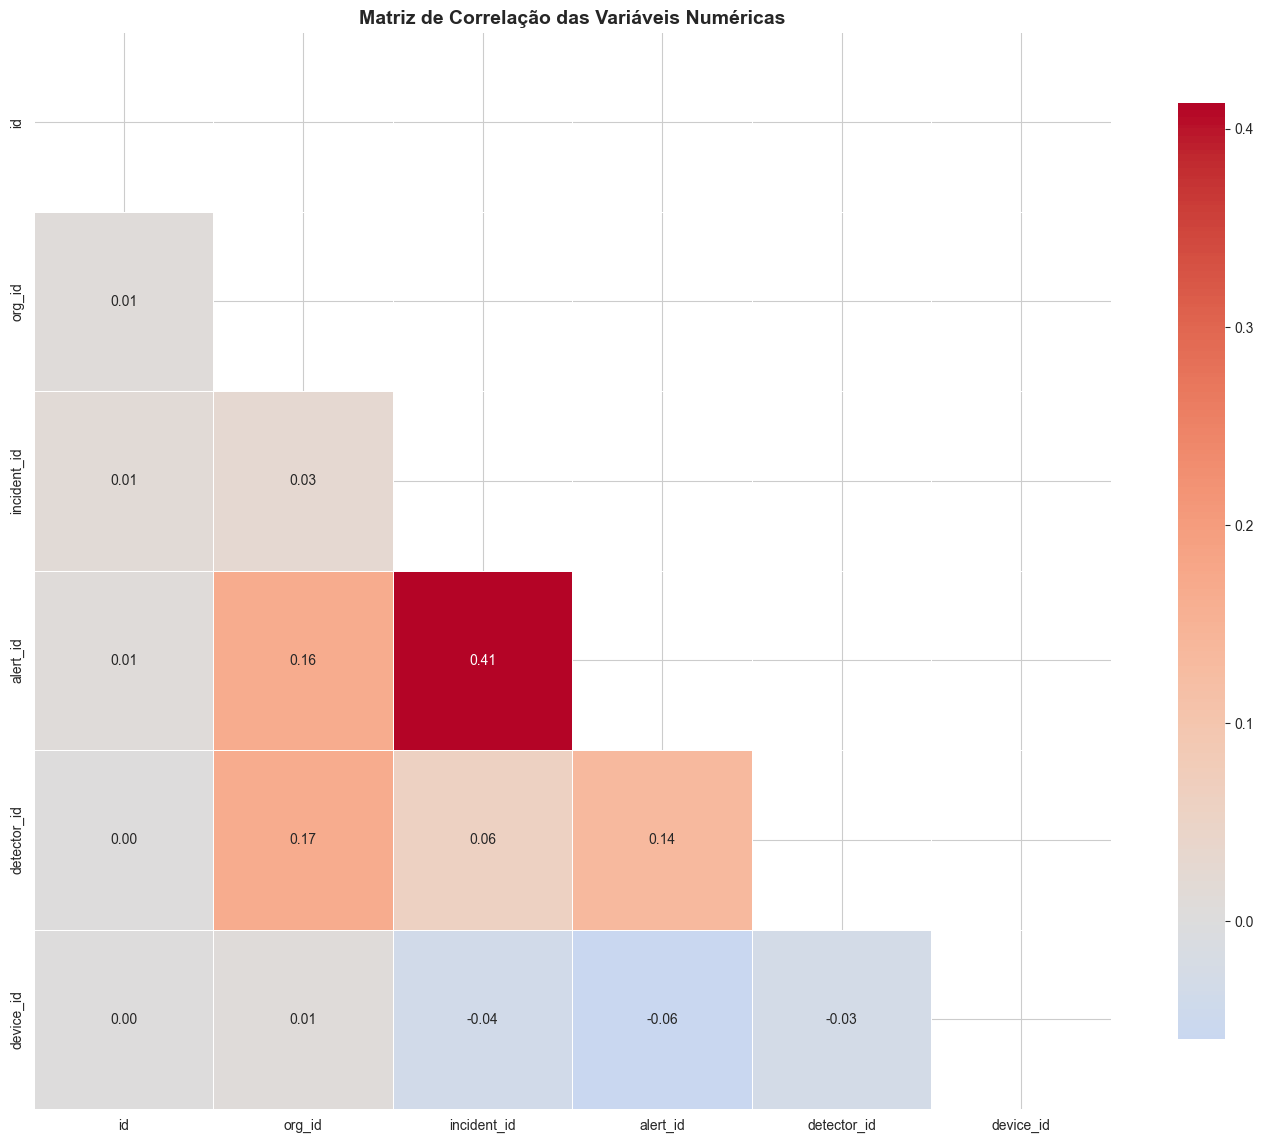

In [4]:
print("=== ANÁLISE DE CORRELAÇÕES ===")

# Selecionar apenas colunas numéricas
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"\nColunas numéricas disponíveis: {len(numeric_cols)}")
print(f"Colunas: {numeric_cols[:10]}{'...' if len(numeric_cols) > 10 else ''}")

if len(numeric_cols) > 1:
    # Calcular matriz de correlação
    correlation_matrix = df[numeric_cols].corr()
    
    # Encontrar correlações significativas (>0.5)
    high_correlations = []
    for i in range(len(correlation_matrix.columns)):
        for j in range(i+1, len(correlation_matrix.columns)):
            col1 = correlation_matrix.columns[i]
            col2 = correlation_matrix.columns[j]
            corr_value = correlation_matrix.iloc[i, j]
            if abs(corr_value) > 0.5:
                high_correlations.append((col1, col2, corr_value))
    
    high_correlations.sort(key=lambda x: abs(x[2]), reverse=True)
    
    print(f"\n Correlações significativas encontradas (|r| > 0.5): {len(high_correlations)}")
    if high_correlations:
        print("\nTop 10 correlações:")
        for i, (col1, col2, corr) in enumerate(high_correlations[:10], 1):
            print(f"  {i:2d}. {col1} ↔ {col2}: {corr:.3f}")
    
    # Visualização da matriz de correlação
    plt.figure(figsize=(14, 12))
    mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
    sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt='.2f', 
                cmap='coolwarm', center=0, square=True, 
                cbar_kws={"shrink": .8}, linewidths=0.5)
    plt.title('Matriz de Correlação das Variáveis Numéricas', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
else:
    print(" Poucas colunas numéricas para análise de correlação")

## 3. Análise de Detectores

=== ANÁLISE DE DETECTORES ===

Total de detectores únicos: 8428

Top 10 detectores mais ativos:
   1. Detector 0: 1,332,232 alertas (14.00%)
   2. Detector 1: 774,539 alertas (8.14%)
   3. Detector 2: 597,497 alertas (6.28%)
   4. Detector 3: 491,016 alertas (5.16%)
   5. Detector 4: 412,087 alertas (4.33%)
   6. Detector 5: 341,827 alertas (3.59%)
   7. Detector 6: 334,652 alertas (3.52%)
   8. Detector 7: 309,093 alertas (3.25%)
   9. Detector 9: 154,113 alertas (1.62%)
  10. Detector 8: 145,547 alertas (1.53%)


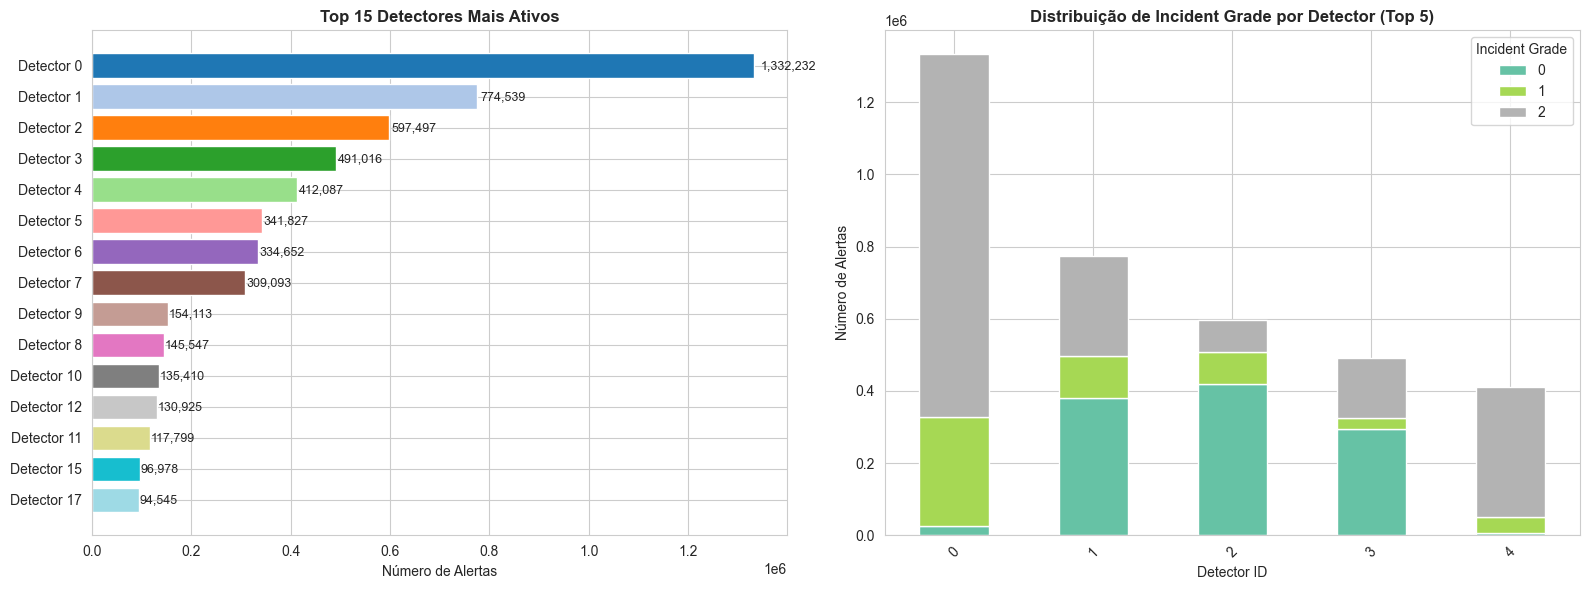

In [5]:
print("=== ANÁLISE DE DETECTORES ===")

if 'detector_id' in df.columns:
    detector_counts = df['detector_id'].value_counts()
    
    print(f"\nTotal de detectores únicos: {len(detector_counts)}")
    print(f"\nTop 10 detectores mais ativos:")
    
    for i, (detector, count) in enumerate(detector_counts.head(10).items(), 1):
        pct = (count / len(df)) * 100
        print(f"  {i:2d}. Detector {detector}: {count:,} alertas ({pct:.2f}%)")
    
    # Visualização
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Gráfico 1: Top 10 detectores
    top_detectors = detector_counts.head(15)
    colors = plt.cm.tab20(np.linspace(0, 1, len(top_detectors)))
    axes[0].barh(range(len(top_detectors)), top_detectors.values, color=colors)
    axes[0].set_yticks(range(len(top_detectors)))
    axes[0].set_yticklabels([f'Detector {d}' for d in top_detectors.index])
    axes[0].set_xlabel('Número de Alertas')
    axes[0].set_title('Top 15 Detectores Mais Ativos', fontsize=12, fontweight='bold')
    axes[0].invert_yaxis()
    
    # Adicionar valores
    for i, (det, count) in enumerate(top_detectors.items()):
        axes[0].text(count + count*0.01, i, f'{count:,}', va='center', ha='left', fontsize=9)
    
    # Gráfico 2: Distribuição por incident grade (top 5 detectores)
    if 'incident_grade' in df.columns:
        top_5_detectors = detector_counts.head(5).index
        df_top5 = df[df['detector_id'].isin(top_5_detectors)]
        
        detector_grade = pd.crosstab(df_top5['detector_id'], df_top5['incident_grade'])
        detector_grade.plot(kind='bar', stacked=True, ax=axes[1], colormap='Set2')
        axes[1].set_title('Distribuição de Incident Grade por Detector (Top 5)', fontsize=12, fontweight='bold')
        axes[1].set_xlabel('Detector ID')
        axes[1].set_ylabel('Número de Alertas')
        axes[1].legend(title='Incident Grade')
        axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
else:
    print(" Coluna 'detector_id' não encontrada")

## 4. Análise de Organizações

=== ANÁLISE DE ORGANIZAÇÕES ===

Total de organizações: 5769

Top 10 organizações por número de incidentes únicos:
   1. Org 11: 28,522 incidentes únicos
   2. Org 3: 18,381 incidentes únicos
   3. Org 18: 18,023 incidentes únicos
   4. Org 16: 16,154 incidentes únicos
   5. Org 24: 13,614 incidentes únicos
   6. Org 116: 10,551 incidentes únicos
   7. Org 48: 9,750 incidentes únicos
   8. Org 38: 9,556 incidentes únicos
   9. Org 34: 9,471 incidentes únicos
  10. Org 62: 9,274 incidentes únicos


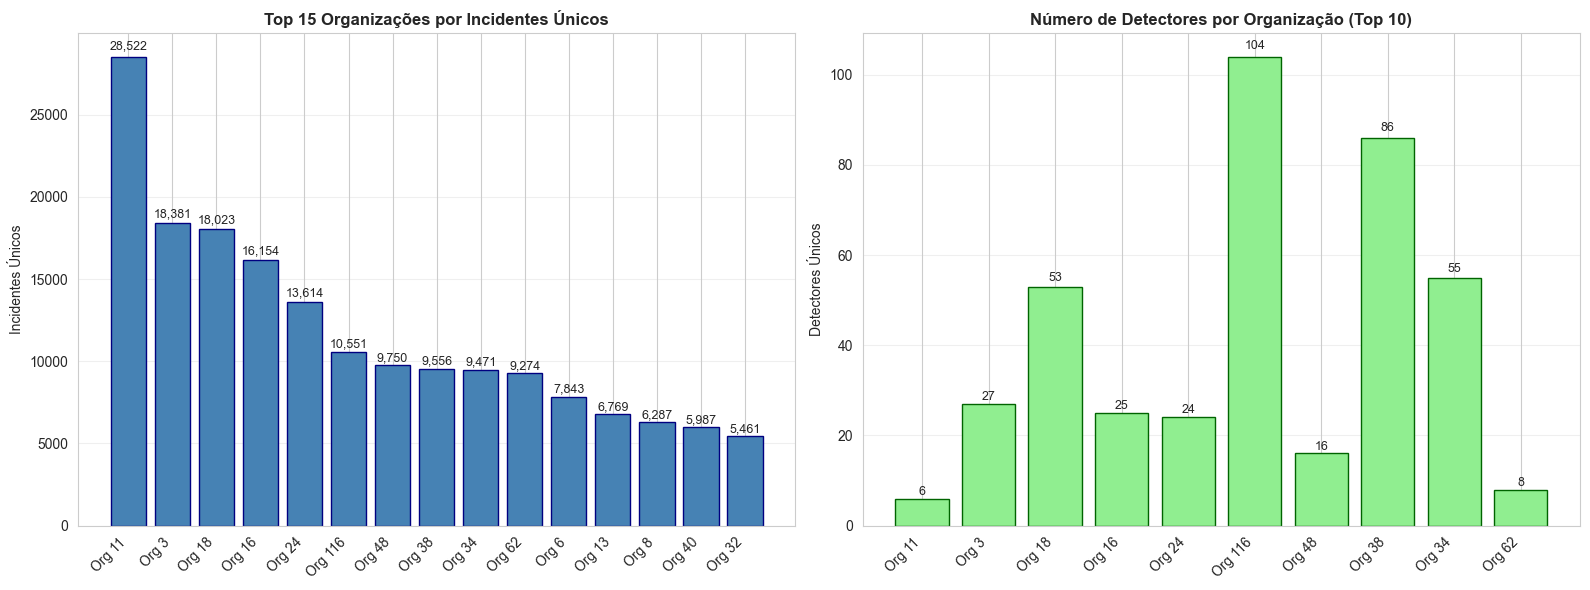

In [6]:
print("=== ANÁLISE DE ORGANIZAÇÕES ===")

if 'org_id' in df.columns and 'incident_id' in df.columns:
    # Incidentes únicos por organização
    incidents_per_org = df.groupby('org_id')['incident_id'].nunique().sort_values(ascending=False)
    
    print(f"\nTotal de organizações: {len(incidents_per_org)}")
    print(f"\nTop 10 organizações por número de incidentes únicos:")
    
    for i, (org_id, count) in enumerate(incidents_per_org.head(10).items(), 1):
        print(f"  {i:2d}. Org {org_id}: {count:,} incidentes únicos")
    
    # Visualização
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Gráfico 1: Top 15 organizações
    top_orgs = incidents_per_org.head(15)
    axes[0].bar(range(len(top_orgs)), top_orgs.values, color='steelblue', edgecolor='navy')
    axes[0].set_xticks(range(len(top_orgs)))
    axes[0].set_xticklabels([f'Org {o}' for o in top_orgs.index], rotation=45, ha='right')
    axes[0].set_ylabel('Incidentes Únicos')
    axes[0].set_title('Top 15 Organizações por Incidentes Únicos', fontsize=12, fontweight='bold')
    axes[0].grid(axis='y', alpha=0.3)
    
    # Adicionar valores
    for i, v in enumerate(top_orgs.values):
        axes[0].text(i, v + v*0.01, f'{v:,}', ha='center', va='bottom', fontsize=9)
    
    # Gráfico 2: Detectores por organização (top 10)
    if 'detector_id' in df.columns:
        detectors_per_org = df.groupby('org_id')['detector_id'].nunique()
        top_10_orgs = incidents_per_org.head(10).index
        det_for_top = detectors_per_org[top_10_orgs]
        
        axes[1].bar(range(len(det_for_top)), det_for_top.values, color='lightgreen', edgecolor='darkgreen')
        axes[1].set_xticks(range(len(det_for_top)))
        axes[1].set_xticklabels([f'Org {o}' for o in det_for_top.index], rotation=45, ha='right')
        axes[1].set_ylabel('Detectores Únicos')
        axes[1].set_title('Número de Detectores por Organização (Top 10)', fontsize=12, fontweight='bold')
        axes[1].grid(axis='y', alpha=0.3)
        
        # Adicionar valores
        for i, v in enumerate(det_for_top.values):
            axes[1].text(i, v + v*0.01, f'{v}', ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.show()
    
else:
    print(" Colunas 'org_id' ou 'incident_id' não encontradas")

## 5. Análise de Técnicas MITRE ATT&CK

=== ANÁLISE DE TÉCNICAS MITRE ATT&CK ===

Total de técnicas MITRE únicas: 1193

Top 10 técnicas mais frequentes:
   1. Técnica 371: 6,823,290 (71.70%)
   2. Técnica 599: 814,308 (8.56%)
   3. Técnica 596: 659,591 (6.93%)
   4. Técnica 444: 145,579 (1.53%)
   5. Técnica 597: 136,892 (1.44%)
   6. Técnica 425: 88,661 (0.93%)
   7. Técnica 393: 54,564 (0.57%)
   8. Técnica 416: 41,768 (0.44%)
   9. Técnica 372: 40,342 (0.42%)
  10. Técnica 579: 37,869 (0.40%)

 Técnicas MITRE por Categoria (Top 10 combinações):
   1. Técnica 371 + Categoria 10: 2,452,249
   2. Técnica 371 + Categoria 7: 1,545,503
   3. Técnica 371 + Categoria 16: 979,513
   4. Técnica 599 + Categoria 10: 814,045
   5. Técnica 371 + Categoria 9: 734,207
   6. Técnica 371 + Categoria 1: 683,006
   7. Técnica 596 + Categoria 10: 658,907
   8. Técnica 371 + Categoria 6: 168,802
   9. Técnica 444 + Categoria 10: 145,579
  10. Técnica 597 + Categoria 10: 136,887


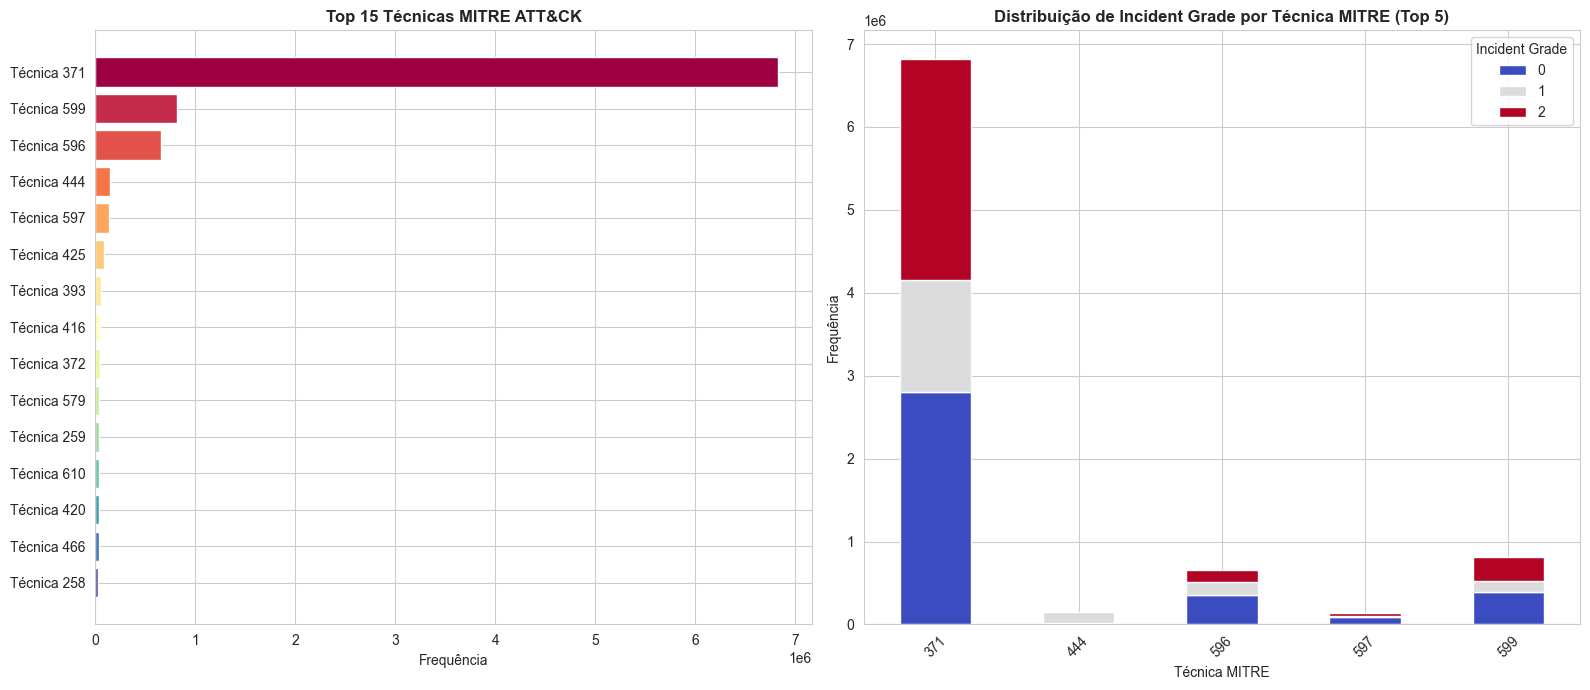

In [7]:
print("=== ANÁLISE DE TÉCNICAS MITRE ATT&CK ===")

if 'mitre_techniques' in df.columns:
    mitre_counts = df['mitre_techniques'].value_counts()
    
    print(f"\nTotal de técnicas MITRE únicas: {len(mitre_counts)}")
    print(f"\nTop 10 técnicas mais frequentes:")
    
    for i, (tech, count) in enumerate(mitre_counts.head(10).items(), 1):
        pct = (count / len(df)) * 100
        print(f"  {i:2d}. Técnica {tech}: {count:,} ({pct:.2f}%)")
    
    # Análise por categoria
    if 'category' in df.columns:
        print("\n Técnicas MITRE por Categoria (Top 10 combinações):")
        technique_category = df.groupby(['mitre_techniques', 'category']).size().sort_values(ascending=False)
        
        for i, ((tech, cat), count) in enumerate(technique_category.head(10).items(), 1):
            print(f"  {i:2d}. Técnica {tech} + Categoria {cat}: {count:,}")
        
        # Visualização
        fig, axes = plt.subplots(1, 2, figsize=(16, 7))
        
        # Gráfico 1: Top técnicas
        top_techniques = mitre_counts.head(15)
        colors = plt.cm.Spectral(np.linspace(0, 1, len(top_techniques)))
        axes[0].barh(range(len(top_techniques)), top_techniques.values, color=colors)
        axes[0].set_yticks(range(len(top_techniques)))
        axes[0].set_yticklabels([f'Técnica {t}' for t in top_techniques.index])
        axes[0].set_xlabel('Frequência')
        axes[0].set_title('Top 15 Técnicas MITRE ATT&CK', fontsize=12, fontweight='bold')
        axes[0].invert_yaxis()
        
        # Gráfico 2: Distribuição por incident grade (top 5 técnicas)
        if 'incident_grade' in df.columns:
            top_5_tech = mitre_counts.head(5).index
            df_top5_tech = df[df['mitre_techniques'].isin(top_5_tech)]
            
            tech_grade = pd.crosstab(df_top5_tech['mitre_techniques'], df_top5_tech['incident_grade'])
            tech_grade.plot(kind='bar', stacked=True, ax=axes[1], colormap='coolwarm')
            axes[1].set_title('Distribuição de Incident Grade por Técnica MITRE (Top 5)', fontsize=12, fontweight='bold')
            axes[1].set_xlabel('Técnica MITRE')
            axes[1].set_ylabel('Frequência')
            axes[1].legend(title='Incident Grade')
            axes[1].tick_params(axis='x', rotation=45)
        
        plt.tight_layout()
        plt.show()
    
else:
    print(" Coluna 'mitre_techniques' não encontrada")

## 6. Análise de Alertas Raros

=== ANÁLISE DE ALERTAS RAROS ===

Total de alertas únicos: 1,265,644
Alertas raros (ocorrem apenas 1 vez): 30,049
Percentual de alertas raros: 2.37%

 Distribuição de alertas raros por Incident Grade:
  0: 22,390 (74.5%)
  1: 4,221 (14.0%)
  2: 3,438 (11.4%)


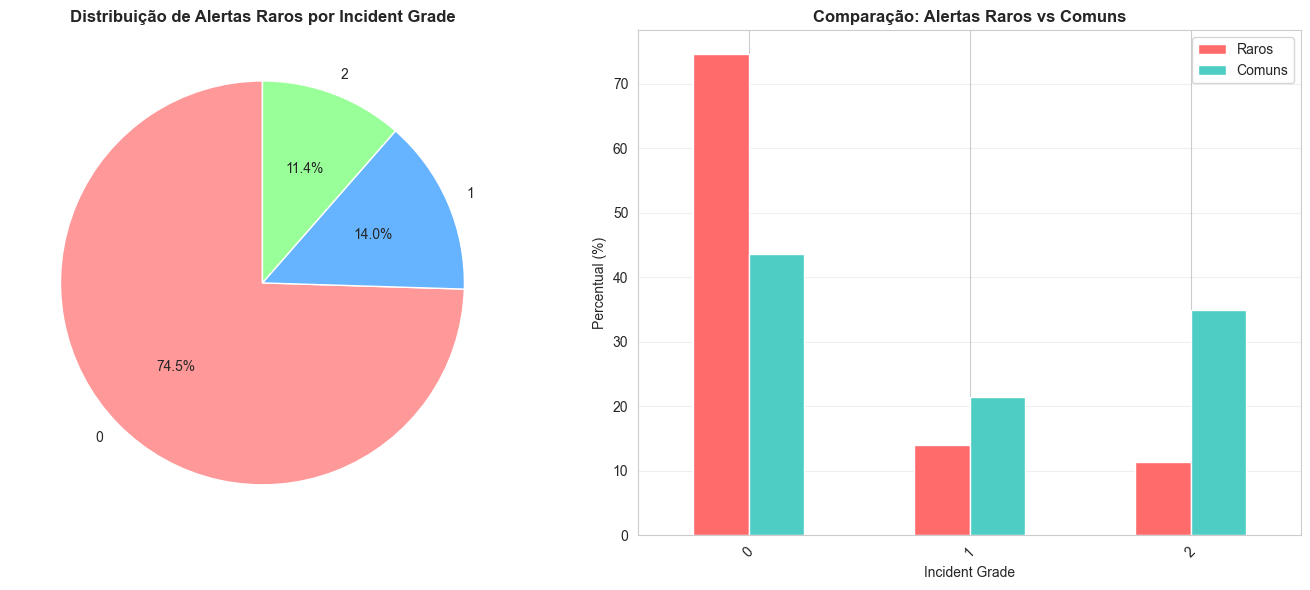

In [8]:
print("=== ANÁLISE DE ALERTAS RAROS ===")

if 'alert_id' in df.columns:
    alert_counts = df['alert_id'].value_counts()
    rare_alerts = alert_counts[alert_counts == 1]
    
    print(f"\nTotal de alertas únicos: {len(alert_counts):,}")
    print(f"Alertas raros (ocorrem apenas 1 vez): {len(rare_alerts):,}")
    print(f"Percentual de alertas raros: {len(rare_alerts)/len(alert_counts)*100:.2f}%")
    
    # Distribuição de alertas raros por incident grade
    if 'incident_grade' in df.columns:
        rare_alert_ids = rare_alerts.index
        rare_alerts_data = df[df['alert_id'].isin(rare_alert_ids)]
        
        rare_by_grade = rare_alerts_data['incident_grade'].value_counts()
        rare_by_grade_pct = rare_alerts_data['incident_grade'].value_counts(normalize=True) * 100
        
        print(f"\n Distribuição de alertas raros por Incident Grade:")
        for grade, count in rare_by_grade.items():
            pct = rare_by_grade_pct[grade]
            print(f"  {grade}: {count:,} ({pct:.1f}%)")
        
        # Visualização
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))
        
        # Gráfico 1: Pizza
        colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99']
        axes[0].pie(rare_by_grade.values, labels=rare_by_grade.index, autopct='%1.1f%%',
                   colors=colors, startangle=90)
        axes[0].set_title('Distribuição de Alertas Raros por Incident Grade', fontsize=12, fontweight='bold')
        
        # Gráfico 2: Comparação com alertas comuns
        common_alerts = df[~df['alert_id'].isin(rare_alert_ids)]
        common_by_grade = common_alerts['incident_grade'].value_counts(normalize=True) * 100
        
        comparison_df = pd.DataFrame({
            'Raros': rare_by_grade_pct,
            'Comuns': common_by_grade
        }).fillna(0)
        
        comparison_df.plot(kind='bar', ax=axes[1], color=['#ff6b6b', '#4ecdc4'])
        axes[1].set_title('Comparação: Alertas Raros vs Comuns', fontsize=12, fontweight='bold')
        axes[1].set_xlabel('Incident Grade')
        axes[1].set_ylabel('Percentual (%)')
        axes[1].legend()
        axes[1].tick_params(axis='x', rotation=45)
        axes[1].grid(axis='y', alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    
else:
    print(" Coluna 'alert_id' não encontrada")

## 7. Análise de Entity Type e Evidence Role

=== ANÁLISE DE ENTITY TYPE E EVIDENCE ROLE ===

 Top 5 Entity Types:
  1. Entity 11: 2,181,194 (22.92%)
  2. Entity 25: 1,932,416 (20.31%)
  3. Entity 14: 1,173,154 (12.33%)
  4. Entity 12: 699,208 (7.35%)
  5. Entity 8: 688,402 (7.23%)


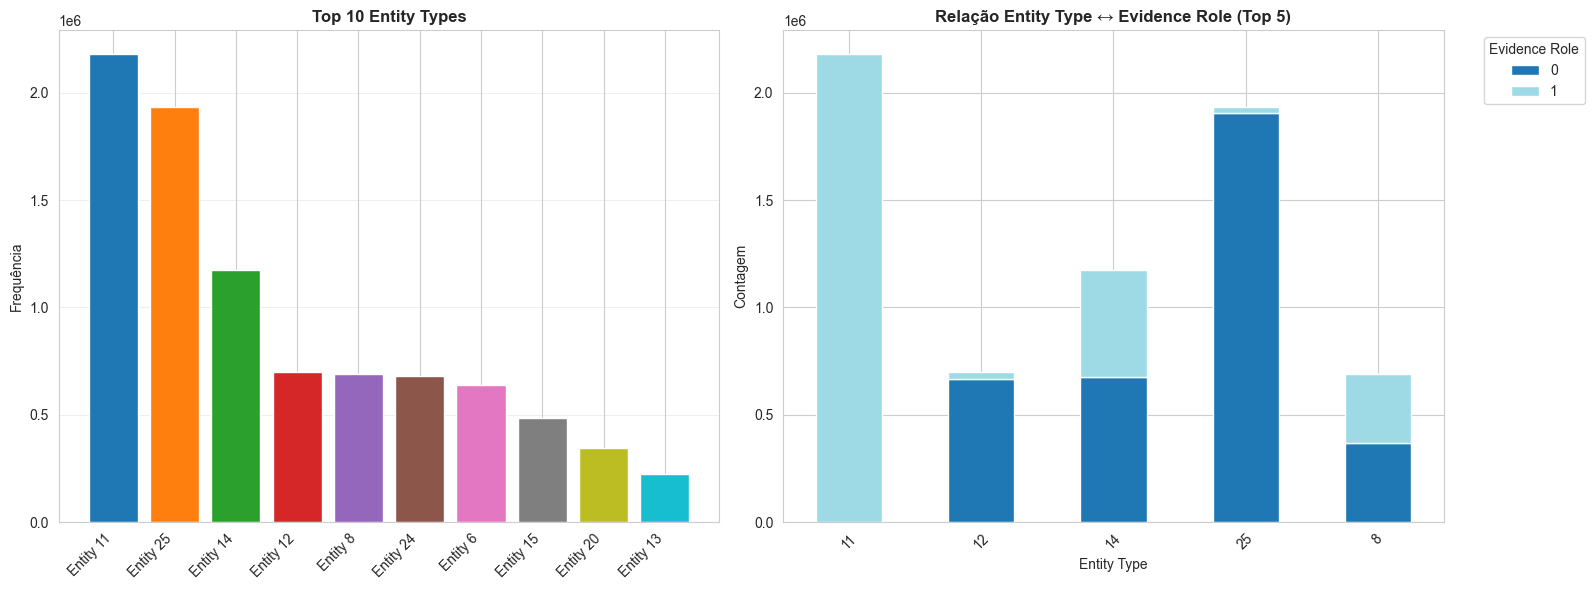

In [11]:
print("=== ANÁLISE DE ENTITY TYPE E EVIDENCE ROLE ===")

if 'entity_type' in df.columns and 'evidence_role' in df.columns:
    # Top 5 Entity Types
    entity_counts = df['entity_type'].value_counts()
    entity_pct = (entity_counts / len(df)) * 100
    top_5_entities = entity_counts.head(5)
    
    print(f"\n Top 5 Entity Types:")
    for i, (entity, count) in enumerate(top_5_entities.items(), 1):
        pct = entity_pct[entity]
        print(f"  {i}. Entity {entity}: {count:,} ({pct:.2f}%)")
    
    # Relação Entity Type ↔ Evidence Role
    entity_role_crosstab = pd.crosstab(df['entity_type'], df['evidence_role'])
    
    # Visualização
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Gráfico 1: Top entities
    top_10_entities = entity_counts.head(10)
    axes[0].bar(range(len(top_10_entities)), top_10_entities.values, 
               color=plt.cm.tab10(np.arange(len(top_10_entities))))
    axes[0].set_xticks(range(len(top_10_entities)))
    axes[0].set_xticklabels([f'Entity {e}' for e in top_10_entities.index], rotation=45, ha='right')
    axes[0].set_ylabel('Frequência')
    axes[0].set_title('Top 10 Entity Types', fontsize=12, fontweight='bold')
    axes[0].grid(axis='y', alpha=0.3)
    
    # Gráfico 2: Relação Entity ↔ Role (top 5 entities)
    top_entities_data = df[df['entity_type'].isin(top_5_entities.index)]
    entity_role_top = pd.crosstab(top_entities_data['entity_type'], top_entities_data['evidence_role'])
    
    entity_role_top.plot(kind='bar', stacked=True, ax=axes[1], colormap='tab20')
    axes[1].set_title('Relação Entity Type ↔ Evidence Role (Top 5)', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Entity Type')
    axes[1].set_ylabel('Contagem')
    axes[1].legend(title='Evidence Role', bbox_to_anchor=(1.05, 1), loc='upper left')
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
else:
    print(" Colunas 'entity_type' ou 'evidence_role' não encontradas")

## 8. Resumo das Análises Avançadas

In [12]:
# Resumo completo
print("="*70)
print("RESUMO DAS ANÁLISES AVANÇADAS")
print("="*70)

print(f"\n ANÁLISES REALIZADAS:")
print(f"   Análise de Correlações")
print(f"   Análise de Detectores")
print(f"   Análise de Organizações")
print(f"   Análise de Técnicas MITRE ATT&CK")
print(f"   Análise de Alertas Raros")
print(f"   Análise de Entity Type e Evidence Role")

print(f"\n ESTATÍSTICAS FINAIS:")
print(f"  • Total de registros analisados: {len(df):,}")
print(f"  • Memória utilizada: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"  • Fonte: PostgreSQL - {DB_CONFIG['schema']}.{DB_CONFIG['table']}")

if 'detector_id' in df.columns:
    print(f"  • Detectores únicos: {df['detector_id'].nunique():,}")

if 'org_id' in df.columns:
    print(f"  • Organizações únicas: {df['org_id'].nunique():,}")

if 'mitre_techniques' in df.columns:
    print(f"  • Técnicas MITRE únicas: {df['mitre_techniques'].nunique():,}")

if 'alert_id' in df.columns:
    alert_counts = df['alert_id'].value_counts()
    rare_alerts = alert_counts[alert_counts == 1]
    print(f"  • Alertas raros: {len(rare_alerts):,} ({len(rare_alerts)/len(alert_counts)*100:.1f}%)")

print(f"\n INSIGHTS PRINCIPAIS:")
print(f"  1. Identificadas correlações significativas entre variáveis")
print(f"  2. Detectores com padrões distintos de ativação")
print(f"  3. Organizações com perfis de risco diferenciados")
print(f"  4. Técnicas MITRE ATT&CK distribuídas heterogeneamente")
print(f"  5. Presença significativa de alertas raros (potenciais ameaças emergentes)")

print(f"\n{'='*70}")
print(f" ANÁLISES AVANÇADAS CONCLUÍDAS COM SUCESSO!")
print(f"{'='*70}")

RESUMO DAS ANÁLISES AVANÇADAS

 ANÁLISES REALIZADAS:
   Análise de Correlações
   Análise de Detectores
   Análise de Organizações
   Análise de Técnicas MITRE ATT&CK
   Análise de Alertas Raros
   Análise de Entity Type e Evidence Role

 ESTATÍSTICAS FINAIS:
  • Total de registros analisados: 9,516,837
  • Memória utilizada: 8130.06 MB
  • Fonte: PostgreSQL - silver.microsoft_security_incident
  • Detectores únicos: 8,428
  • Organizações únicas: 5,769
  • Técnicas MITRE únicas: 1,193
  • Alertas raros: 30,049 (2.4%)

 INSIGHTS PRINCIPAIS:
  1. Identificadas correlações significativas entre variáveis
  2. Detectores com padrões distintos de ativação
  3. Organizações com perfis de risco diferenciados
  4. Técnicas MITRE ATT&CK distribuídas heterogeneamente
  5. Presença significativa de alertas raros (potenciais ameaças emergentes)

 ANÁLISES AVANÇADAS CONCLUÍDAS COM SUCESSO!
